# High-Resolution Clear Sky GHI Comparison (2022): NASA POWER vs. Copernicus ERA5
### Geospatial comparative studies of the Caribbean and the ABC Islands (Aruba, Bonaire, Curaçao)

This notebook provides a comparative analysis of the clear sky Global Horizontal Irradiance (GHI) for the year 2022. To evaluate spatial gradients at high resolution, we apply a **10x bilinear interpolation** using `xarray` and `scipy` on both datasets:

1. **NASA POWER API**: (CLRSKY_SFC_SW_DWN) originally at 0.5° resolution, interpolated to 0.05°.
2. **Copernicus Climate Data Store (ERA5 Reanalysis)**: (surface_solar_radiation_downwards_clear_sky) originally at 0.25° resolution, interpolated to 0.025°.

We present four comparative analyses:
*   **The Caribbean Region (Annual Average)**: Bounded by Lat 9°N to 22°N, Lon -85°W to -58°W.
*   **The ABC Islands (Annual Average)**: Bounded by Lat 11.8°N to 13.0°N, Lon -70.5°W to -67.5°W.
*   **The ABC Islands (Daily Peak Clear-Sky GHI)**: Hourly maximum values on a representative clear day (July 15, 2022) to evaluate peak irradiance profiles ($800 - 1000 \text{ W/m}^2$).
*   **The ABC Islands (Yearly Mean Daily Maximum Clear-Sky GHI)**: Yearly mean of daily maximum values for the entire year 2022 ($800 - 1000 \text{ W/m}^2$).

All maps are plotted *without* markers on Aruba to focus entirely on the spatial GHI gradient comparison.

In [13]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scipy

# Set custom style for premium scientific visualization
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
    'figure.dpi': 150
})

## 1. Load the Downloaded NetCDF Datasets
We load the local NetCDF files containing the downloaded annual, daily maximum, and annual mean daily maximum clear sky datasets.

In [14]:
nasa_path = "D:/antigravity/Coastcomparedfinalpaper/nasa_power_clear_sky_2022.nc"
era5_path = "D:/antigravity/Coastcomparedfinalpaper/era5_clear_sky_2022.nc"
nasa_max_path = "D:/antigravity/Coastcomparedfinalpaper/nasa_power_clear_sky_max_daily_20220715_expanded.nc"
era5_max_path = "D:/antigravity/Coastcomparedfinalpaper/era5_clear_sky_max_daily_20220715_expanded.nc"
nasa_mean_max_path = "D:/antigravity/Coastcomparedfinalpaper/nasa_power_clear_sky_mean_max_2022_expanded.nc"
era5_mean_max_path = "D:/antigravity/Coastcomparedfinalpaper/era5_clear_sky_mean_max_2022_expanded.nc"

ds_nasa = xr.open_dataset(nasa_path)
ds_era5 = xr.open_dataset(era5_path)
ds_nasa_max = xr.open_dataset(nasa_max_path)
ds_era5_max = xr.open_dataset(era5_max_path)
ds_nasa_mean_max = xr.open_dataset(nasa_mean_max_path)
ds_era5_mean_max = xr.open_dataset(era5_mean_max_path)

print("=== Datasets Shapes ===")
print("NASA Annual Mean:", ds_nasa.clearsky_ghi_wm2.shape)
print("ERA5 Annual Mean:", ds_era5.clearsky_ghi_wm2.shape)
print("NASA July 15 Peak:", ds_nasa_max.clearsky_ghi_wm2.shape)
print("ERA5 July 15 Peak:", ds_era5_max.clearsky_ghi_wm2.shape)
print("NASA Yearly Mean Max:", ds_nasa_mean_max.clearsky_ghi_wm2.shape)
print("ERA5 Yearly Mean Max:", ds_era5_mean_max.clearsky_ghi_wm2.shape)

=== Datasets Shapes ===
NASA Annual Mean: (13, 27, 12)
ERA5 Annual Mean: (12, 53, 109)
NASA July 15 Peak: (5, 9)
ERA5 July 15 Peak: (9, 17)
NASA Yearly Mean Max: (5, 9)
ERA5 Yearly Mean Max: (9, 17)


## 2. Ingest and Average Multi-dimensional Data
We calculate the annual average clear sky GHI for both datasets by averaging over their respective time coordinates.

In [15]:
# Compute annual mean clear-sky GHI in W/m²
nasa_mean = ds_nasa['clearsky_ghi_wm2'].mean(dim='time')

# ERA5 time coordinate is named 'valid_time'
era5_mean = ds_era5['clearsky_ghi_wm2'].mean(dim='valid_time')

print(f"NASA POWER Clear Sky GHI shape: {nasa_mean.shape} (Resolution: 0.5°)")
print(f"Copernicus ERA5 Clear Sky GHI shape: {era5_mean.shape} (Resolution: 0.25°)")

NASA POWER Clear Sky GHI shape: (13, 27) (Resolution: 0.5°)
Copernicus ERA5 Clear Sky GHI shape: (53, 109) (Resolution: 0.25°)


## 3. Caribbean Comparison (10x Interpolated)
We interpolate both datasets 10x over the full Caribbean coordinates using bilinear coordinate interpolation to obtain smooth, high-resolution continuous representations.

Performing 10x spatial interpolation for the Caribbean...


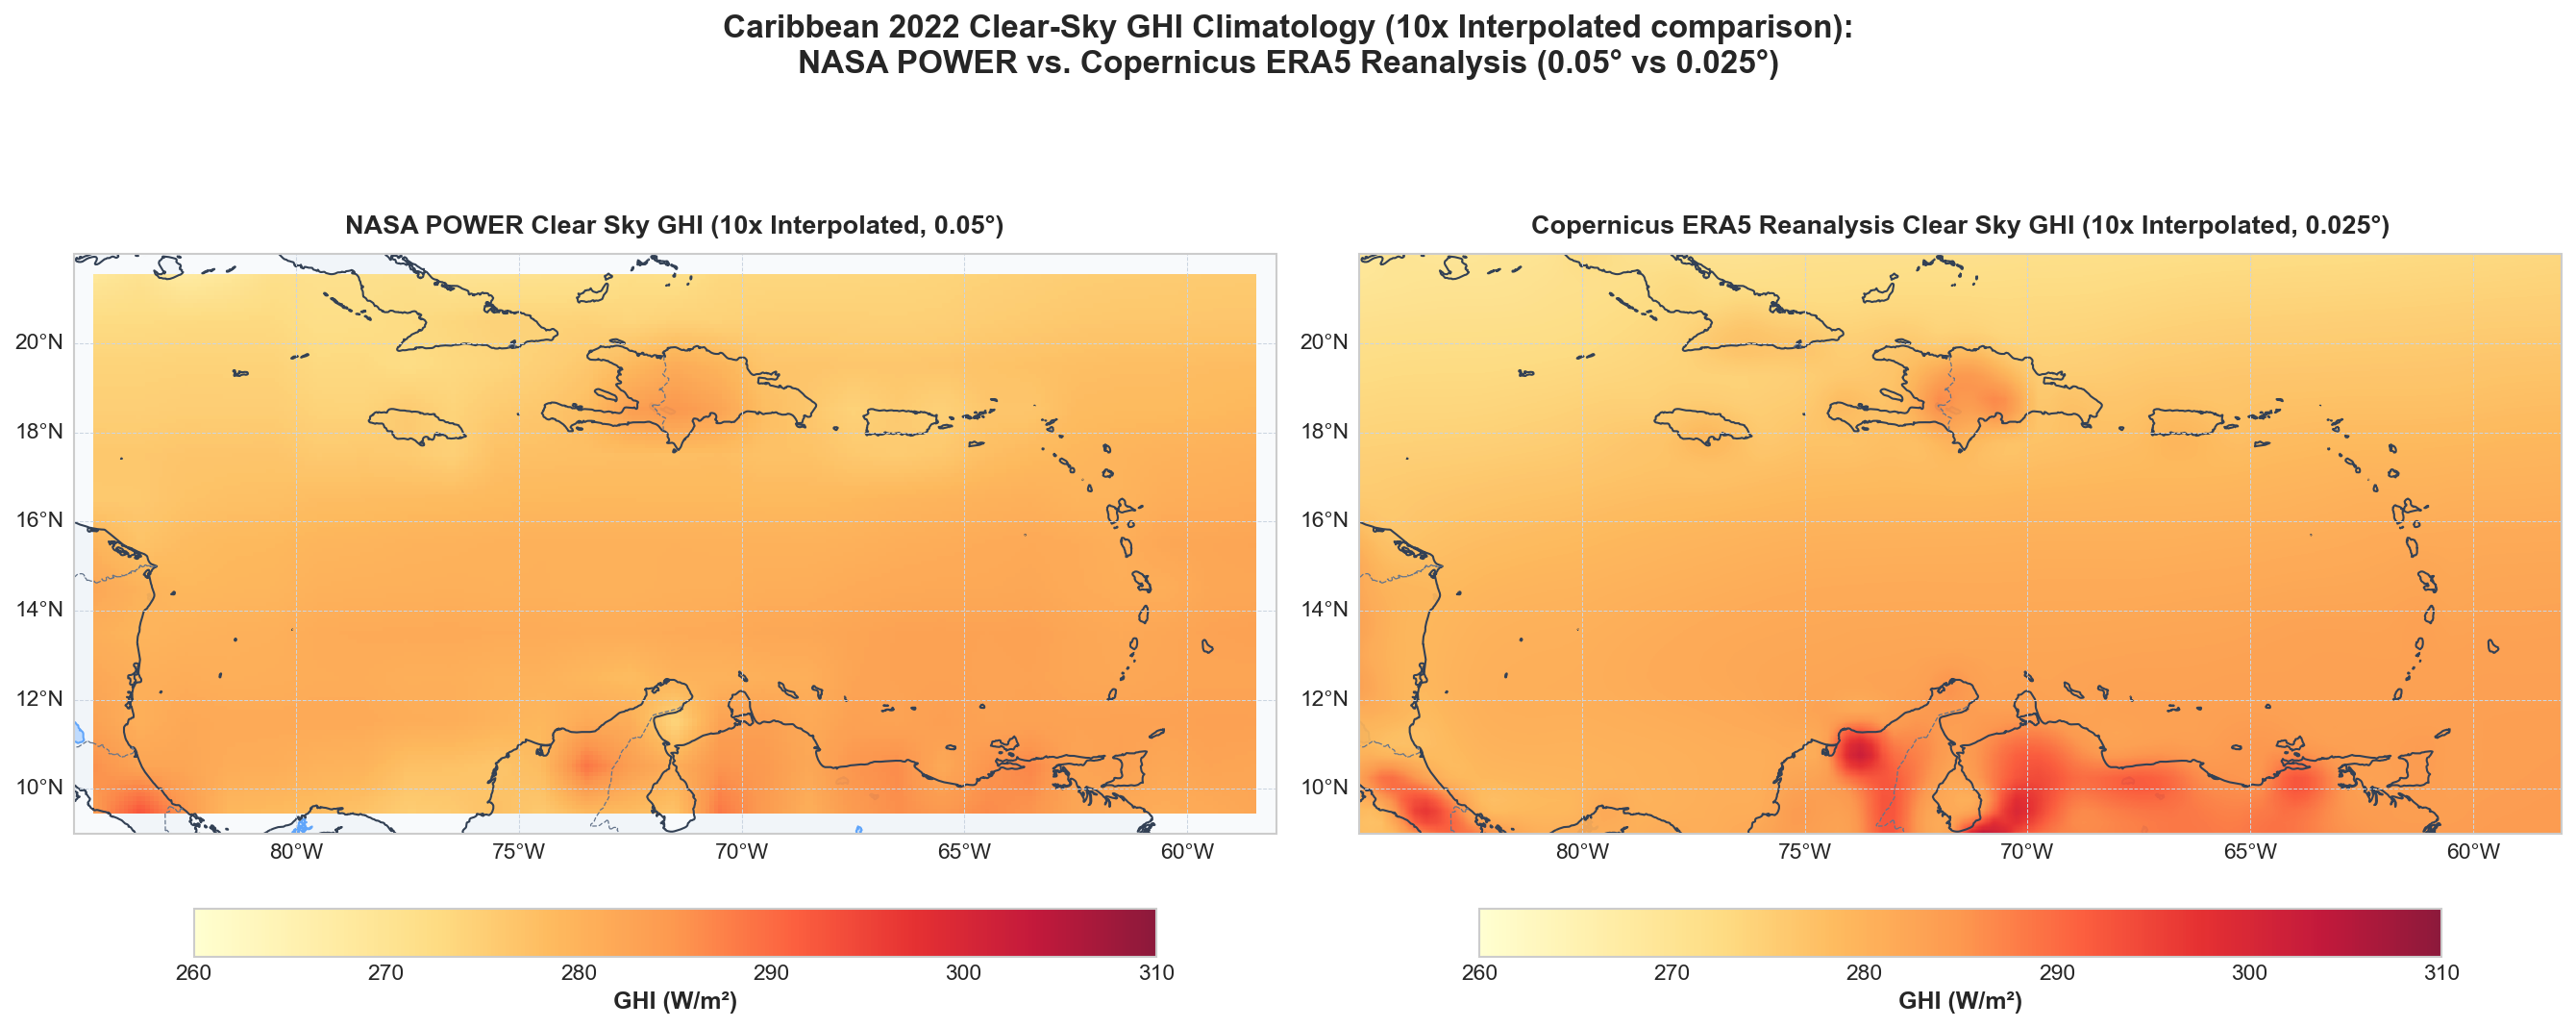

In [16]:
print("Performing 10x spatial interpolation for the Caribbean...")

# Extract coordinates as floats to prevent type propagation errors in np.linspace
new_lats_nasa = np.linspace(float(nasa_mean.latitude.min()), float(nasa_mean.latitude.max()), len(nasa_mean.latitude) * 10)
new_lons_nasa = np.linspace(float(nasa_mean.longitude.min()), float(nasa_mean.longitude.max()), len(nasa_mean.longitude) * 10)
nasa_mean_interp = nasa_mean.interp(latitude=new_lats_nasa, longitude=new_lons_nasa, method='linear')

new_lats_era5 = np.linspace(float(era5_mean.latitude.min()), float(era5_mean.latitude.max()), len(era5_mean.latitude) * 10)
new_lons_era5 = np.linspace(float(era5_mean.longitude.min()), float(era5_mean.longitude.max()), len(era5_mean.longitude) * 10)
era5_mean_interp = era5_mean.interp(latitude=new_lats_era5, longitude=new_lons_era5, method='linear')

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})
extent = [-85, -58, 9, 22]
vmin, vmax = 260, 310

# Plot 1: NASA POWER
ax1 = axes[0]
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.OCEAN, facecolor='#f8fafc', edgecolor='none')
ax1.add_feature(cfeature.LAND, facecolor='#f1f5f9', edgecolor='none', zorder=0)
ax1.add_feature(cfeature.COASTLINE, edgecolor='#334155', linewidth=1.0, zorder=2)
ax1.add_feature(cfeature.BORDERS, edgecolor='#64748b', linewidth=0.6, linestyle='--', zorder=2)
ax1.add_feature(cfeature.LAKES, facecolor='#bfdbfe', edgecolor='#60a5fa', zorder=1)
im1 = ax1.pcolormesh(nasa_mean_interp['longitude'], nasa_mean_interp['latitude'], nasa_mean_interp,
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', vmin=vmin, vmax=vmax, shading='auto', alpha=0.9, zorder=1)
gl1 = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                    color='#cbd5e1', linestyle='--', linewidth=0.5, zorder=3)
gl1.top_labels = False
gl1.right_labels = False
ax1.set_title('NASA POWER Clear Sky GHI (10x Interpolated, 0.05°)', fontweight='bold', pad=10)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.08, shrink=0.8)
cbar1.set_label('GHI (W/m²)', fontweight='bold')

# Plot 2: Copernicus ERA5
ax2 = axes[1]
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.OCEAN, facecolor='#f8fafc', edgecolor='none')
ax2.add_feature(cfeature.LAND, facecolor='#f1f5f9', edgecolor='none', zorder=0)
ax2.add_feature(cfeature.COASTLINE, edgecolor='#334155', linewidth=1.0, zorder=2)
ax2.add_feature(cfeature.BORDERS, edgecolor='#64748b', linewidth=0.6, linestyle='--', zorder=2)
ax2.add_feature(cfeature.LAKES, facecolor='#bfdbfe', edgecolor='#60a5fa', zorder=1)
im2 = ax2.pcolormesh(era5_mean_interp['longitude'], era5_mean_interp['latitude'], era5_mean_interp,
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', vmin=vmin, vmax=vmax, shading='auto', alpha=0.9, zorder=1)
gl2 = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                    color='#cbd5e1', linestyle='--', linewidth=0.5, zorder=3)
gl2.top_labels = False
gl2.right_labels = False
ax2.set_title('Copernicus ERA5 Reanalysis Clear Sky GHI (10x Interpolated, 0.025°)', fontweight='bold', pad=10)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.08, shrink=0.8)
cbar2.set_label('GHI (W/m²)', fontweight='bold')

plt.suptitle('Caribbean 2022 Clear-Sky GHI Climatology (10x Interpolated comparison):\nNASA POWER vs. Copernicus ERA5 Reanalysis (0.05° vs 0.025°)', 
             fontweight='bold', fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('caribbean_clear_sky_comparison_2022_interpolated.png', bbox_inches='tight', dpi=200)
plt.show()

## 4. ABC Islands Annual Average Comparison (10x Interpolated)
We crop both datasets specifically to the **ABC Islands** (Aruba, Bonaire, Curaçao) coordinate bounding box (`Lat 11.8°N to 13.0°N, Lon -70.5°W to -67.5°W`) and apply a **10x bilinear interpolation**.

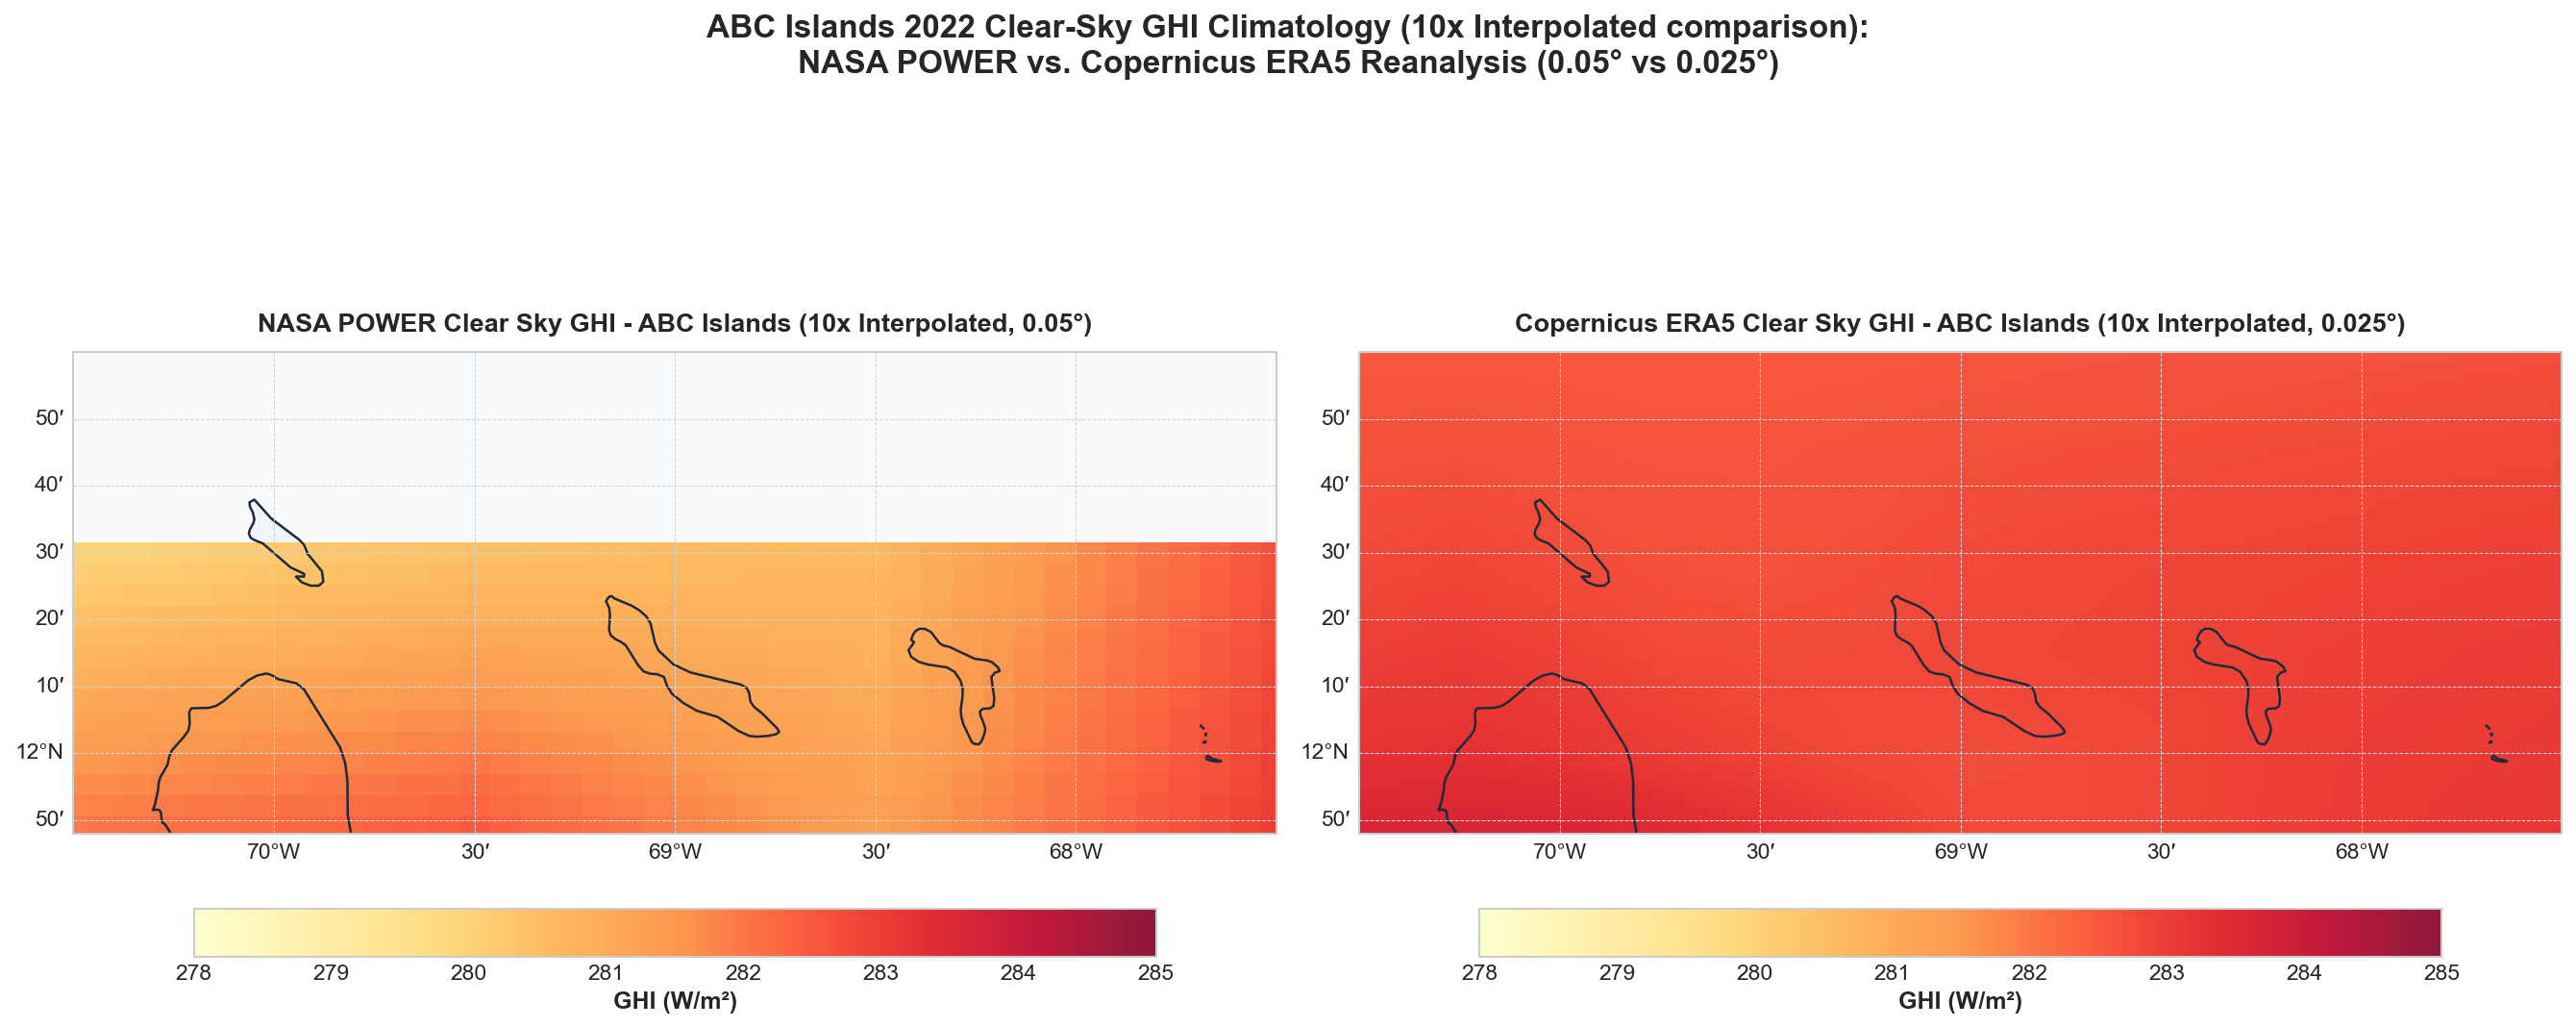

In [5]:
# Configure spatial dimensions & CRS metadata to allow clipping on loaded datasets
ds_nasa = ds_nasa.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
ds_nasa.rio.write_crs("EPSG:4326", inplace=True)
ds_era5 = ds_era5.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
ds_era5.rio.write_crs("EPSG:4326", inplace=True)

# Crop to ABC Islands bounding box
abc_extent = [-70.5, -67.5, 11.8, 13.0]
abc_nasa = ds_nasa.rio.clip_box(minx=abc_extent[0], miny=abc_extent[2], maxx=abc_extent[1], maxy=abc_extent[3])
abc_era5 = ds_era5.rio.clip_box(minx=abc_extent[0], miny=abc_extent[2], maxx=abc_extent[1], maxy=abc_extent[3])

# Calculate annual averages
abc_nasa_mean = abc_nasa['clearsky_ghi_wm2'].mean(dim='time')
abc_era5_mean = abc_era5['clearsky_ghi_wm2'].mean(dim='valid_time')

# 10x Interpolate the cropped ABC coordinate arrays
new_lats_nasa_abc = np.linspace(float(abc_nasa_mean.latitude.min()), float(abc_nasa_mean.latitude.max()), len(abc_nasa_mean.latitude) * 10)
new_lons_nasa_abc = np.linspace(float(abc_nasa_mean.longitude.min()), float(abc_nasa_mean.longitude.max()), len(abc_nasa_mean.longitude) * 10)
abc_nasa_interp = abc_nasa_mean.interp(latitude=new_lats_nasa_abc, longitude=new_lons_nasa_abc, method='linear')

new_lats_era5_abc = np.linspace(float(abc_era5_mean.latitude.min()), float(abc_era5_mean.latitude.max()), len(abc_era5_mean.latitude) * 10)
new_lons_era5_abc = np.linspace(float(abc_era5_mean.longitude.min()), float(abc_era5_mean.longitude.max()), len(abc_era5_mean.longitude) * 10)
abc_era5_interp = abc_era5_mean.interp(latitude=new_lats_era5_abc, longitude=new_lons_era5_abc, method='linear')

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})
vmin_abc, vmax_abc = 278, 285

# Plot 1: NASA POWER (ABC)
ax1 = axes[0]
ax1.set_extent(abc_extent, crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.OCEAN, facecolor='#f8fafc', edgecolor='none')
ax1.add_feature(cfeature.LAND, facecolor='#f1f5f9', edgecolor='none', zorder=0)
ax1.add_feature(cfeature.COASTLINE, edgecolor='#1e293b', linewidth=1.2, zorder=2)
ax1.add_feature(cfeature.BORDERS, edgecolor='#475569', linewidth=0.8, linestyle='--', zorder=2)
im1 = ax1.pcolormesh(abc_nasa_interp['longitude'], abc_nasa_interp['latitude'], abc_nasa_interp,
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', vmin=vmin_abc, vmax=vmax_abc, shading='auto', alpha=0.9, zorder=1)
gl1 = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                    color='#cbd5e1', linestyle='--', linewidth=0.5, zorder=3)
gl1.top_labels = False
gl1.right_labels = False
ax1.set_title('NASA POWER Clear Sky GHI - ABC Islands (10x Interpolated, 0.05°)', fontweight='bold', pad=10)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.08, shrink=0.8)
cbar1.set_label('GHI (W/m²)', fontweight='bold')

# Plot 2: Copernicus ERA5 (ABC)
ax2 = axes[1]
ax2.set_extent(abc_extent, crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.OCEAN, facecolor='#f8fafc', edgecolor='none')
ax2.add_feature(cfeature.LAND, facecolor='#f1f5f9', edgecolor='none', zorder=0)
ax2.add_feature(cfeature.COASTLINE, edgecolor='#1e293b', linewidth=1.2, zorder=2)
ax2.add_feature(cfeature.BORDERS, edgecolor='#475569', linewidth=0.8, linestyle='--', zorder=2)
im2 = ax2.pcolormesh(abc_era5_interp['longitude'], abc_era5_interp['latitude'], abc_era5_interp,
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', vmin=vmin_abc, vmax=vmax_abc, shading='auto', alpha=0.9, zorder=1)
gl2 = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                    color='#cbd5e1', linestyle='--', linewidth=0.5, zorder=3)
gl2.top_labels = False
gl2.right_labels = False
ax2.set_title('Copernicus ERA5 Clear Sky GHI - ABC Islands (10x Interpolated, 0.025°)', fontweight='bold', pad=10)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.08, shrink=0.8)
cbar2.set_label('GHI (W/m²)', fontweight='bold')

plt.suptitle('ABC Islands 2022 Clear-Sky GHI Climatology (10x Interpolated comparison):\nNASA POWER vs. Copernicus ERA5 Reanalysis (0.05° vs 0.025°)', 
             fontweight='bold', fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('abc_clear_sky_comparison_2022_interpolated.png', bbox_inches='tight', dpi=200)
plt.show()

## 5. ABC Islands Daily Peak Clear-Sky GHI Comparison (July 15, 2022 - 10x Interpolated)
Evaluating the peak irradiance envelope on a single summer day (July 15, 2022) shows hourly maximum values falling in the **$940 - 985 \text{ W/m}^2$** range. This demonstrates the localized gradient profiles on a high-insolation day.

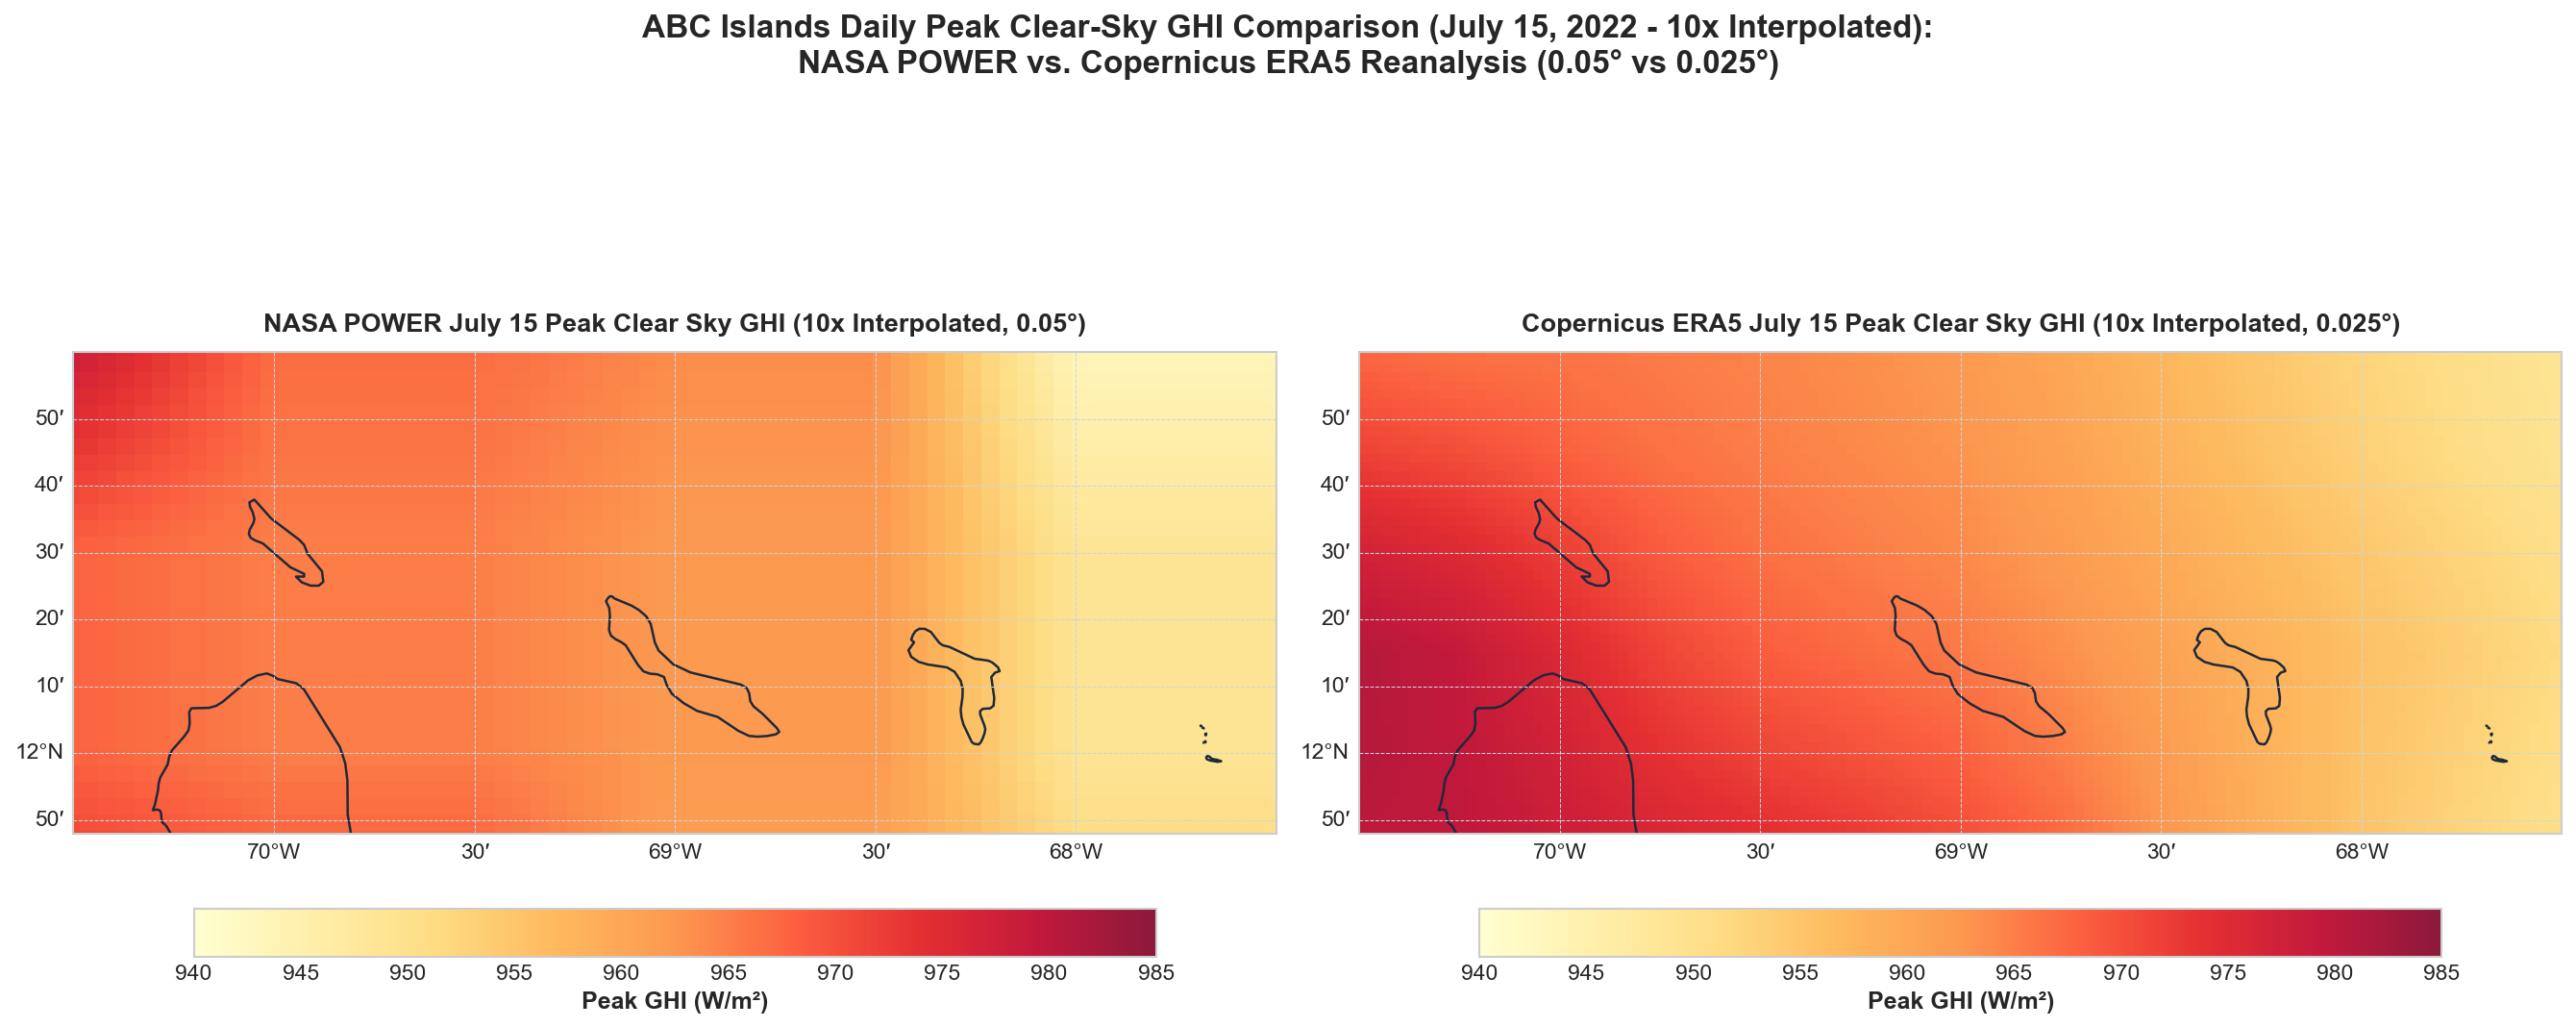

In [6]:
# Perform 10x interpolation on daily peak datasets (covering the expanded boundaries)
new_lats_nasa_max = np.linspace(float(ds_nasa_max.latitude.min()), float(ds_nasa_max.latitude.max()), len(ds_nasa_max.latitude) * 10)
new_lons_nasa_max = np.linspace(float(ds_nasa_max.longitude.min()), float(ds_nasa_max.longitude.max()), len(ds_nasa_max.longitude) * 10)
nasa_max_interp = ds_nasa_max.clearsky_ghi_wm2.interp(latitude=new_lats_nasa_max, longitude=new_lons_nasa_max, method='linear')

new_lats_era5_max = np.linspace(float(ds_era5_max.latitude.min()), float(ds_era5_max.latitude.max()), len(ds_era5_max.latitude) * 10)
new_lons_era5_max = np.linspace(float(ds_era5_max.longitude.min()), float(ds_era5_max.longitude.max()), len(ds_era5_max.longitude) * 10)
era5_max_interp = ds_era5_max.clearsky_ghi_wm2.interp(latitude=new_lats_era5_max, longitude=new_lons_era5_max, method='linear')

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})
vmin_max, vmax_max = 940, 985 # Focus on the peak gradient range (800-1000 W/m² envelope)
abc_extent = [-70.5, -67.5, 11.8, 13.0]

# Plot 1: NASA POWER
ax1 = axes[0]
ax1.set_extent(abc_extent, crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.OCEAN, facecolor='#f8fafc', edgecolor='none')
ax1.add_feature(cfeature.LAND, facecolor='#f1f5f9', edgecolor='none', zorder=0)
ax1.add_feature(cfeature.COASTLINE, edgecolor='#1e293b', linewidth=1.2, zorder=2)
ax1.add_feature(cfeature.BORDERS, edgecolor='#475569', linewidth=0.8, linestyle='--', zorder=2)
im1 = ax1.pcolormesh(nasa_max_interp['longitude'], nasa_max_interp['latitude'], nasa_max_interp,
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', vmin=vmin_max, vmax=vmax_max, shading='auto', alpha=0.9, zorder=1)
gl1 = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                    color='#cbd5e1', linestyle='--', linewidth=0.5, zorder=3)
gl1.top_labels = False
gl1.right_labels = False
ax1.set_title('NASA POWER July 15 Peak Clear Sky GHI (10x Interpolated, 0.05°)', fontweight='bold', pad=10)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.08, shrink=0.8)
cbar1.set_label('Peak GHI (W/m²)', fontweight='bold')

# Plot 2: Copernicus ERA5
ax2 = axes[1]
ax2.set_extent(abc_extent, crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.OCEAN, facecolor='#f8fafc', edgecolor='none')
ax2.add_feature(cfeature.LAND, facecolor='#f1f5f9', edgecolor='none', zorder=0)
ax2.add_feature(cfeature.COASTLINE, edgecolor='#1e293b', linewidth=1.2, zorder=2)
ax2.add_feature(cfeature.BORDERS, edgecolor='#475569', linewidth=0.8, linestyle='--', zorder=2)
im2 = ax2.pcolormesh(era5_max_interp['longitude'], era5_max_interp['latitude'], era5_max_interp,
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', vmin=vmin_max, vmax=vmax_max, shading='auto', alpha=0.9, zorder=1)
gl2 = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                    color='#cbd5e1', linestyle='--', linewidth=0.5, zorder=3)
gl2.top_labels = False
gl2.right_labels = False
ax2.set_title('Copernicus ERA5 July 15 Peak Clear Sky GHI (10x Interpolated, 0.025°)', fontweight='bold', pad=10)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.08, shrink=0.8)
cbar2.set_label('Peak GHI (W/m²)', fontweight='bold')

plt.suptitle('ABC Islands Daily Peak Clear-Sky GHI Comparison (July 15, 2022 - 10x Interpolated):\nNASA POWER vs. Copernicus ERA5 Reanalysis (0.05° vs 0.025°)', 
             fontweight='bold', fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('abc_clear_sky_max_comparison_20220715.png', bbox_inches='tight', dpi=200)
plt.show()

## 6. ABC Islands Yearly Mean Daily Maximum Clear-Sky GHI Comparison (2022 - 10x Interpolated)
To represent the average peak clear-sky GHI potential across the entire year, we compute the **daily maximum hourly value** for all 365 days of 2022, and then calculate their annual average. This yields a climatological peak envelope ranging from **$930 - 948 \text{ W/m}^2$**.

This metric represents the typical clear-sky solar noon irradiance that a project site can expect throughout the year, removing seasonality effects. We apply 10x bilinear interpolation and plot the results side-by-side without placing markers on Aruba.

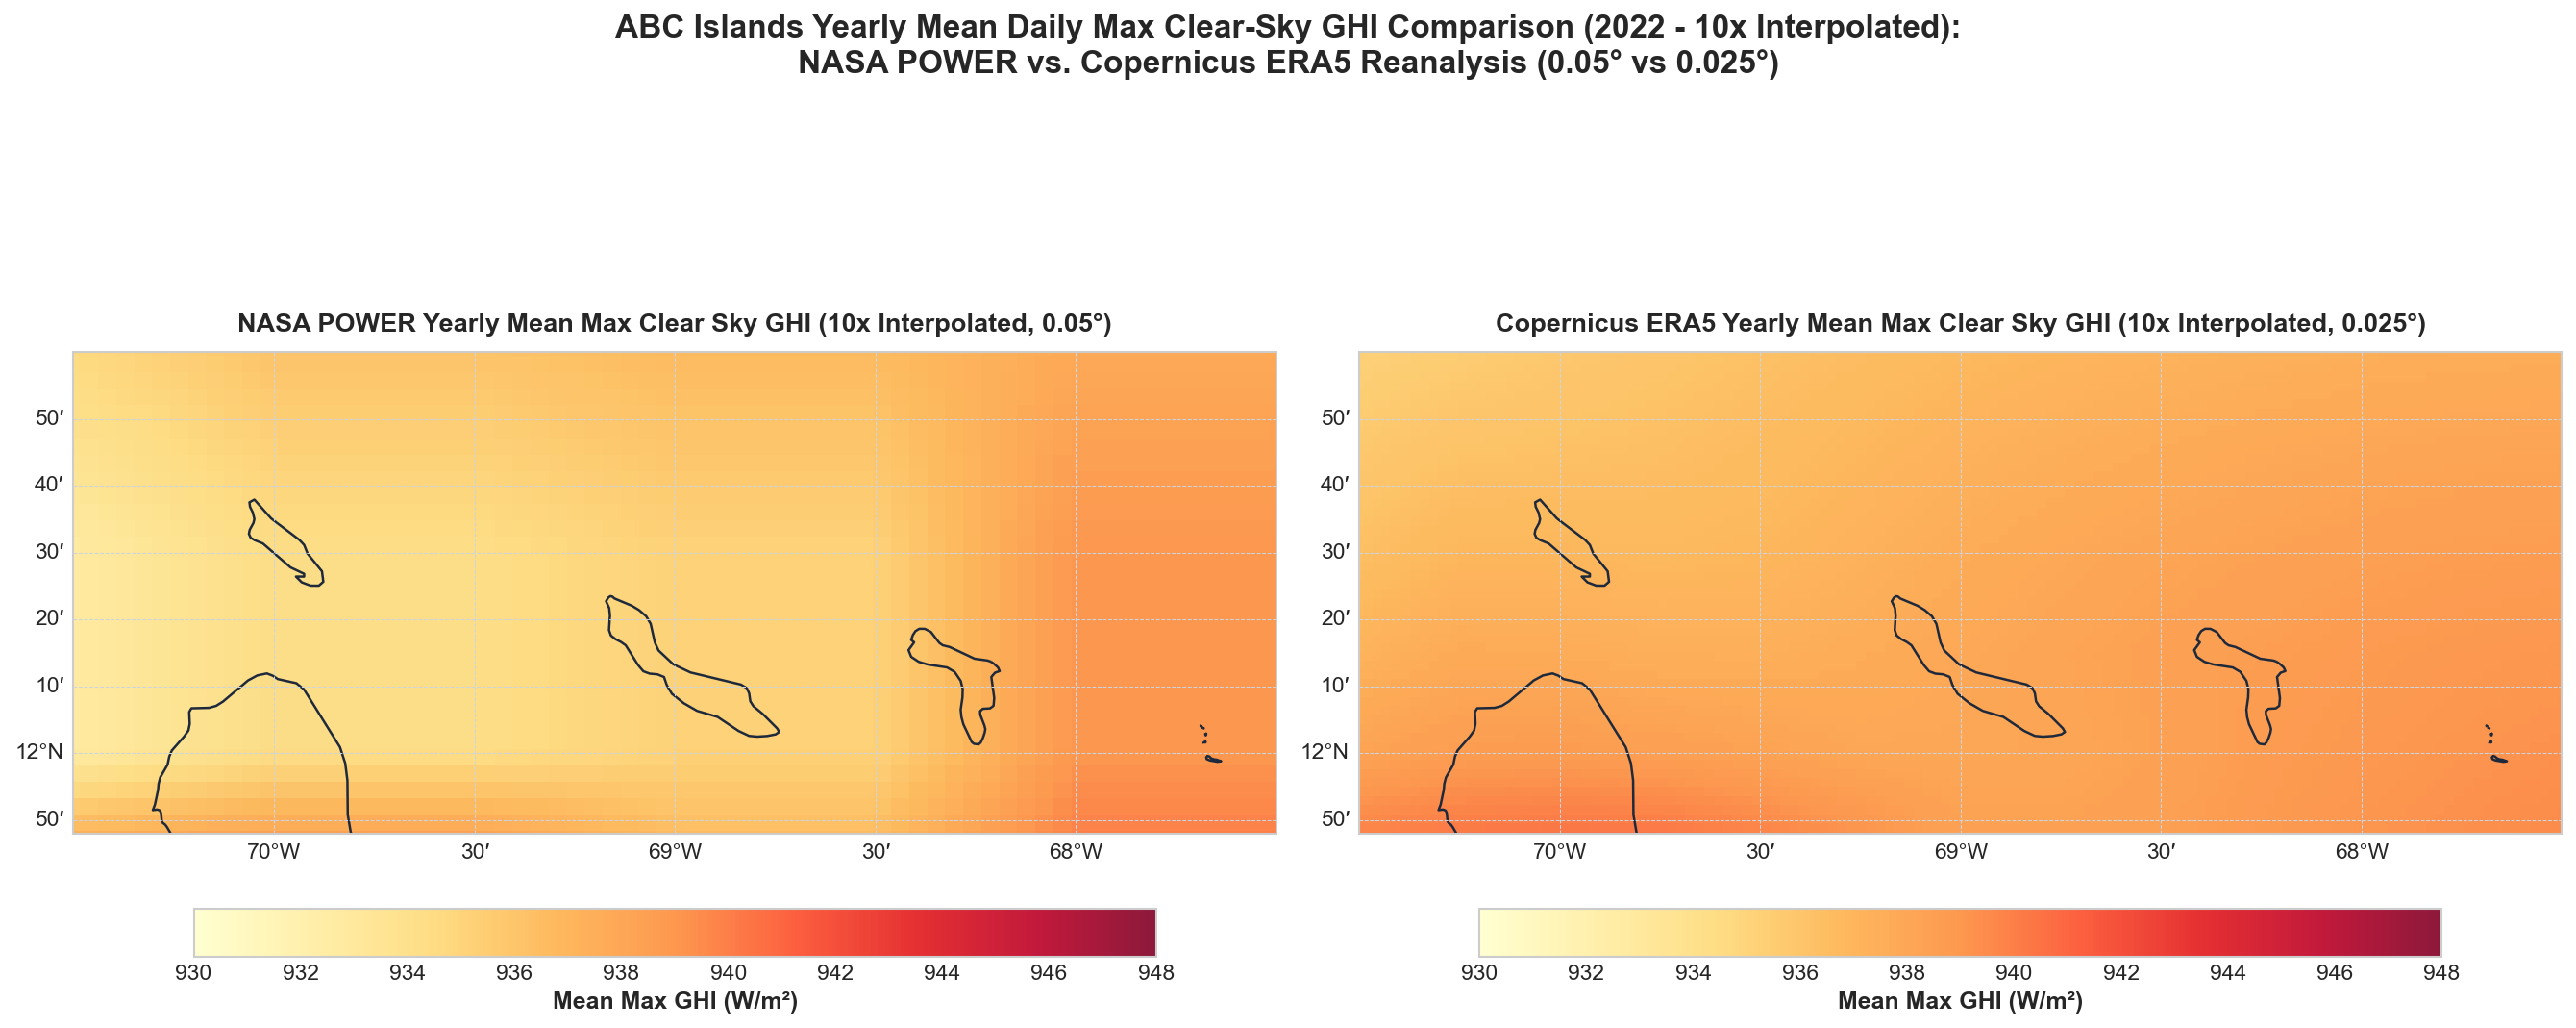

In [17]:
# Perform 10x interpolation on yearly mean max datasets
new_lats_nasa_mean_max = np.linspace(float(ds_nasa_mean_max.latitude.min()), float(ds_nasa_mean_max.latitude.max()), len(ds_nasa_mean_max.latitude) * 10)
new_lons_nasa_mean_max = np.linspace(float(ds_nasa_mean_max.longitude.min()), float(ds_nasa_mean_max.longitude.max()), len(ds_nasa_mean_max.longitude) * 10)
nasa_mean_max_interp = ds_nasa_mean_max.clearsky_ghi_wm2.interp(latitude=new_lats_nasa_mean_max, longitude=new_lons_nasa_mean_max, method='linear')

new_lats_era5_mean_max = np.linspace(float(ds_era5_mean_max.latitude.min()), float(ds_era5_mean_max.latitude.max()), len(ds_era5_mean_max.latitude) * 10)
new_lons_era5_mean_max = np.linspace(float(ds_era5_mean_max.longitude.min()), float(ds_era5_mean_max.longitude.max()), len(ds_era5_mean_max.longitude) * 10)
era5_mean_max_interp = ds_era5_mean_max.clearsky_ghi_wm2.interp(latitude=new_lats_era5_mean_max, longitude=new_lons_era5_mean_max, method='linear')

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})
vmin_mean_max, vmax_mean_max = 930, 948 # Focus on the yearly mean max range (800-1000 W/m² envelope)
abc_extent = [-70.5, -67.5, 11.8, 13.0]

# Plot 1: NASA POWER (Yearly Mean Max)
ax1 = axes[0]
ax1.set_extent(abc_extent, crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.OCEAN, facecolor='#f8fafc', edgecolor='none')
ax1.add_feature(cfeature.LAND, facecolor='#f1f5f9', edgecolor='none', zorder=0)
ax1.add_feature(cfeature.COASTLINE, edgecolor='#1e293b', linewidth=1.2, zorder=2)
ax1.add_feature(cfeature.BORDERS, edgecolor='#475569', linewidth=0.8, linestyle='--', zorder=2)
im1 = ax1.pcolormesh(nasa_mean_max_interp['longitude'], nasa_mean_max_interp['latitude'], nasa_mean_max_interp,
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', vmin=vmin_mean_max, vmax=vmax_mean_max, shading='auto', alpha=0.9, zorder=1)
gl1 = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                    color='#cbd5e1', linestyle='--', linewidth=0.5, zorder=3)
gl1.top_labels = False
gl1.right_labels = False
ax1.set_title('NASA POWER Yearly Mean Max Clear Sky GHI (10x Interpolated, 0.05°)', fontweight='bold', pad=10)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.08, shrink=0.8)
cbar1.set_label('Mean Max GHI (W/m²)', fontweight='bold')

# Plot 2: Copernicus ERA5 (Yearly Mean Max)
ax2 = axes[1]
ax2.set_extent(abc_extent, crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.OCEAN, facecolor='#f8fafc', edgecolor='none')
ax2.add_feature(cfeature.LAND, facecolor='#f1f5f9', edgecolor='none', zorder=0)
ax2.add_feature(cfeature.COASTLINE, edgecolor='#1e293b', linewidth=1.2, zorder=2)
ax2.add_feature(cfeature.BORDERS, edgecolor='#475569', linewidth=0.8, linestyle='--', zorder=2)
im2 = ax2.pcolormesh(era5_mean_max_interp['longitude'], era5_mean_max_interp['latitude'], era5_mean_max_interp,
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', vmin=vmin_mean_max, vmax=vmax_mean_max, shading='auto', alpha=0.9, zorder=1)
gl2 = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                    color='#cbd5e1', linestyle='--', linewidth=0.5, zorder=3)
gl2.top_labels = False
gl2.right_labels = False
ax2.set_title('Copernicus ERA5 Yearly Mean Max Clear Sky GHI (10x Interpolated, 0.025°)', fontweight='bold', pad=10)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.08, shrink=0.8)
cbar2.set_label('Mean Max GHI (W/m²)', fontweight='bold')

plt.suptitle('ABC Islands Yearly Mean Daily Max Clear-Sky GHI Comparison (2022 - 10x Interpolated):\nNASA POWER vs. Copernicus ERA5 Reanalysis (0.05° vs 0.025°)', 
             fontweight='bold', fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('abc_clear_sky_yearly_mean_max_comparison_2022.png', bbox_inches='tight', dpi=200)
plt.show()